This notebook walks through building **backpropagation from scratch** for a simple neural network, covering:

- The `Value` class: data storage with `_prev`, `_op`, `_grad`
- Computation graph visualization with `graphviz`
- Manual → automatic gradient computation via topological sort
- A fully refactored `Value` class supporting `tanh`, `exp`, division, and scalar operations

## 目录 (Table of Contents)

- [1. The Data Storage Architecture](#s1)
- [2. BackPropagation](#s2)
  - [2.1 Basic Chain Rule — How a Node Contributes to the Output](#s21)
  - [2.2 Simple Neural Network](#s22)
  - [2.3 Activation Function (tanh)](#s23)
  - [2.4 `_backward` — Manual Backpropagation](#s24)
  - [2.5 Automatic Backpropagation (Topological Sort)](#s25)
  - [2.6 Full Refactor — Supporting `exp`, Division & Scalar Ops](#s26)

## <a id="s1"></a>1. The data storage architecture

In [14]:
#Building the computation graph
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._grad = 0
        self.label = label

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

    def __repr__(self):
        return f"Value(data={self.data})"
    
    


In [15]:
#graphviz 
from graphviz import Digraph


# fill the nodes and edges containers
def trace(root):
    nodes, edges = set(), set()
    def build(v):#v is a node
        if v not in nodes: #nodes is a union of set
            nodes.add(v)# fill the nodes container
            # now we need to fill the edges container
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

#draw the computation flow chart
def draw_dot(root):
    #get data from the root
    #set the format of the graph,让图从左往右流向（符合直觉）
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    #get the nodes and edges
    nodes, edges = trace(root)
    for n in nodes:
        # get the unique id of the node
        uid=str(id(n))
        # set the format of the node,what to show in the node
        label = "{ %s | data %.4f | grad %.4f }" %(n.label, n.data, n._grad) #define what to show in the node
        dot.node(name=uid, label=label, shape='record')#these 3 parameters are basic
        if n._op:
            dot.node(name=uid + n._op, label = n._op)#define the operator,what to show in the operator
            dot.edge(uid + n._op, uid)#define the edge, <from the operator to the node>
    
    for n1, n2 in edges:#n1 is children, n2 is parent
        dot.edge(str(id(n1)), str(id(n2)) + n2._op) #from the children to the operator
    return dot
    

Value(data=3)


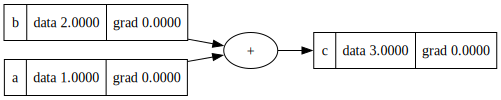

In [16]:
#Define the expression
a = Value(1,label='a')
b = Value(2,label='b')
c = a + b
c.label='c'
print(c)
 
draw_dot(c)


## <a id="s2"></a>2. BackPropagation

### <a id="s21"></a>2.1 Basic of chainrule to know how a node contributes to the output
In the case below here, dc/db=a, dc/da=b.

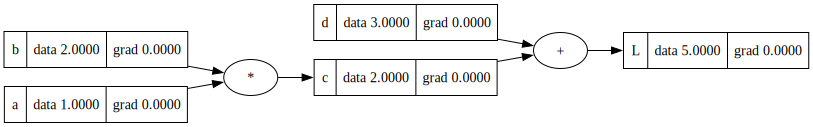

In [17]:
a=Value(1,label='a')
b=Value(2,label='b')
c=a*b; c.label='c'
d=Value(3,label='d')
L=c+d
L.label='L'
draw_dot(L)




how do we derive dL/dc?
dL/da= dL/dc* dc/da

In [18]:
#define the derivative of the node
def lol():
    h=0.0001
    a=Value(1,label='a')
    b=Value(2,label='b')
    c=a*b; c.label='c'
    d=Value(3,label='d')
    L=c+d
    L.label='L'

    a=Value(1+h,label='a')
    b=Value(2,label='b')
    c=a*b; c.label='c'
    d=Value(3,label='d')
    L1=c+d
    L1.label='L1'
    L1=c+d
    dL = (L1.data-L.data)/h
    print(dL)

lol()

1.9999999999953388



### <a id="s22"></a>2.2 Simple Neural Network

image: ![神经网络](/Users/wangzhijie/Documents/GitHub/DeepL/resource/typical_neural_network.png)

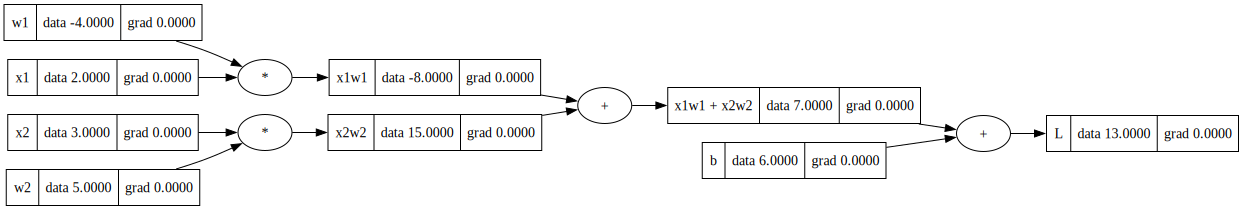

In [19]:
# Build a simple neural network
# Inputs x1,x2
x1=Value(2,label='x1')
x2=Value(3,label='x2')
# Weights w1,w2
w1=Value(-4,label='w1')
w2=Value(5,label='w2')
# Bias b
b=Value(6,label='b')
# Define the expression
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2=x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
L=x1w1x2w2 + b;L.label='L'

# Draw the computation flow chart
draw_dot(L)

### <a id="s23"></a>2.3 Activation Function (tanh)

- tanh is one of the activation function to add unlinear features into the expression to have better adaptability to all kinds of situations.

What is the tanh? A function's values almost only have -1,0,1
$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$

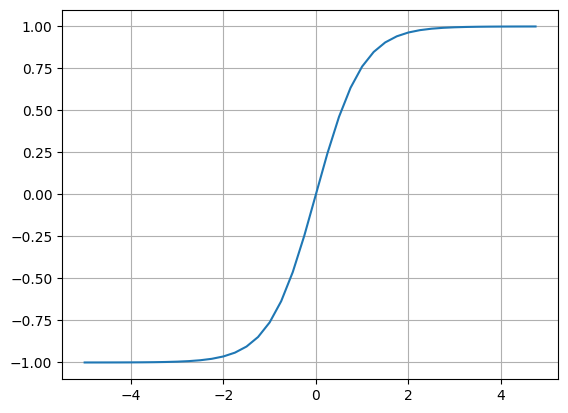

In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#inline：意思是把 Matplotlib 画出来的图，直接嵌入（inline）到当前 notebook 的输出区域里显示（一般以 PNG/SVG 的形式），而不是弹出一个独立窗口。

x=np.arange(-5,5,0.25)
y=np.tanh(x)
plt.plot(x,y)
plt.grid()
plt.show()


now let's add the tanh into the class Value as a new function

In [21]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._grad = 0
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')    

    #add the tanh function
    def tanh(self):
        x=self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')
        return out
        

And about the new mathematical expression: 
(Don't forget to run the graphviz funciton before plotting)

In [22]:
# Build a simple neural network
# Inputs x1,x2
x1=Value(2,label='x1')
x2=Value(3,label='x2')
# Weights w1,w2
w1=Value(-4,label='w1')
w2=Value(5,label='w2')
# Bias b
b=Value(6,label='b')
# Define the expression
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2=x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
L=x1w1x2w2 + b;L.label='L'
o=L.tanh(); o.label='o'


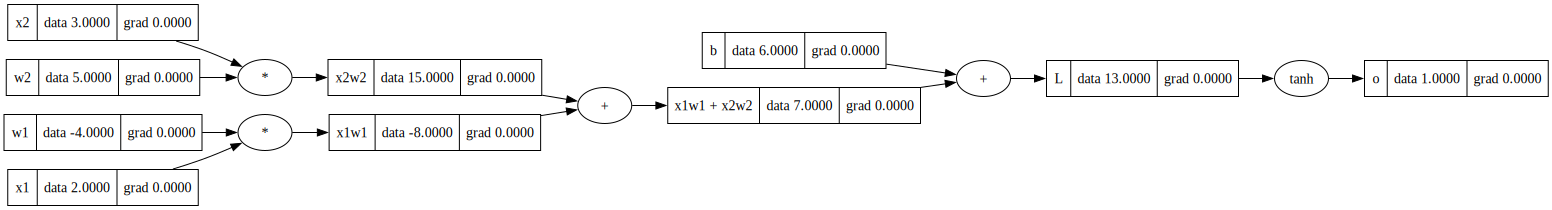

In [23]:
# Draw the computation flow chart
draw_dot(o)

now let's focus on the chain rule and write the backpropagation function.
u need to know here dx1=w1.data * dx1w1

In [24]:
o._grad=1.0


### <a id="s24"></a>2.4 `_backward` — Manual Backpropagation

now we build the backward computation and change the Value class

搞清楚3层关系： `dLoss/dout`, `dout/dx`(out._grad),`dLoss/dx`(local derivative, `self._grad`)

- 一般只要研究dy/dx这个是什么？不同的运算结果不同，对于dy/dx:
    - 对于加法：y=x+a+b+c; =1
    - 对于乘法：y=x*b*c; = other.data (here is bc)
    - 对于tanh: 




In [25]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._grad = 0
        self.label = label
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out= Value(self.data + other.data, (self, other), '+')
        def _backward():
            self._grad += 1.0 * out._grad #use += instead of =
            other._grad += 1.0 * out._grad #use += instead of =
        # when we call node._backward(), it will call the _backward function; for instance,h= a+b+c, when we call h._backward(), it will call the _backward function of a+b+c
        out._backward = _backward #if we add bracket here, it will call the _backward function immediately and return None; 
        #ONLY after we build the full graph, we can call the _backward function
        return out

    
    def __mul__(self, other):
        out= Value(self.data * other.data, (self, other), '*')    
        def _backward():
            self._grad += other.data * out._grad #use += instead of =
            other._grad += self.data * out._grad #use += instead of =
        out._backward = _backward
        return out

    #add the tanh function
    def tanh(self):
        x=self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')
        def _backward():
            self._grad += (1-t**2) * out._grad #use += instead of =
        out._backward = _backward
        return out



In [26]:
# Build a simple neural network
# Inputs x1,x2
x1=Value(2,label='x1')
x2=Value(3,label='x2')
# Weights w1,w2
w1=Value(-4,label='w1')
w2=Value(5,label='w2')
# Bias b
b=Value(6,label='b')
# Define the expression
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2=x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
L=x1w1x2w2 + b;L.label='L'
o=L.tanh(); o.label='o'

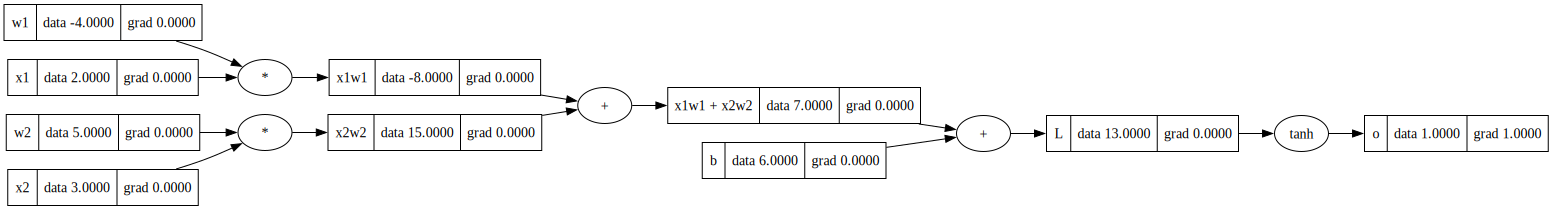

In [27]:
o._grad=1.0
draw_dot(o)

In [28]:
o._grad = 1.0      # 对输出的梯度种子
o._backward()      # 把梯度从 o 传回到 L（tanh 那一层）
L._backward()      # L 再把梯度传到 x1w1x2w2 和 b
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()


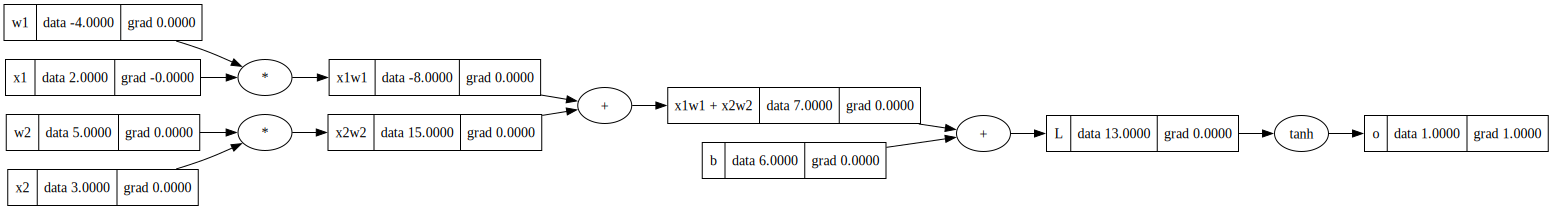

In [29]:
draw_dot(o)

### <a id="s25"></a>2.5 Automatic Backpropagation (Topological Sort)
自动调度整个计算图中所有节点的梯度计算顺序，确保链式法则能正确执行。具体通过Topological Sort确保在调用某个节点的 _backward() 之前，所有依赖它的“上游节点”（即计算图中的父节点）都已经完成了梯度的计算。

注意此时主要是关注父子关系，反向传播需要从“父母（Loss）流向孩子（Inputs）”. 如计算例子：`L = d * f，d = a + b`；我们要确保先执行 L._backward()（填好 d.grad），再执行 d._backward()（利用 d.grad 填好 a.grad）；

这个父子顺序`[input1, input2, output]` or `[output, input2, input1]`怎么来？定义了一个def build_topo(v): (递归函数):
- `topo = [] & visited = set():`创建2个变量记录关系和进度
    -  visited 集合用来防止重复处理同一个节点（因为一个节点可能被多个后续节点使用），也防止死循环（虽然 在这个特定的计算图 DAG 中通常不会有循环）。
    - topo 列表用来按顺序存储节点。
- for child in v._prev:：它先递归地处理当前节点 v 的所有孩子节点（即 _prev 中存储的输入节点）
- topo.append(v)：关键点。只有当所有的孩子都处理完了，才把当前节点 v 加入列表
- 使用 reversed(topo) 将顺序反转，变成 [父母, 孩子]

In [30]:
o._prev=1.0 # 设置输出节点的梯度种子, 一定为1
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)# 只有当所有的孩子都处理完了，才把当前节点 v 加入列表
build_topo(o)# 从输出节点开始，构建拓扑排序
for node in reversed(topo): #确保topo 是先后再前
    node._backward() # 从后往前，依次执行每个节点的 _backward() 方法
topo

TypeError: 'float' object is not iterable

then, let's add this automatic backpropagation into the Value class

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._grad = 0
        self.label = label
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out= Value(self.data + other.data, (self, other), '+')
        def _backward():
            self._grad += 1.0 * out._grad
            other._grad += 1.0 * out._grad
        # when we call node._backward(), it will call the _backward function; for instance,h= a+b+c, when we call h._backward(), it will call the _backward function of a+b+c
        out._backward = _backward #if we add bracket here, it will call the _backward function immediately and return None; 
        #ONLY after we build the full graph, we can call the _backward function
        return out

    
    def __mul__(self, other):
        out= Value(self.data * other.data, (self, other), '*')    
        def _backward():
            self._grad += other.data * out._grad
            other._grad += self.data * out._grad
        out._backward = _backward
        return out

    #add the tanh function
    def tanh(self):
        x=self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')
        def _backward():
            self._grad += (1-t**2) * out._grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self._grad=1.0 # 设置输出节点的梯度种子, 一定为1
        for node in reversed(topo):
            node._backward()


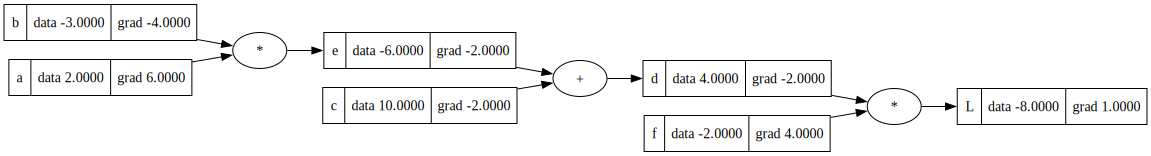

In [ ]:
#Now we use the same expression as in the video
# 初始化输入变量（带标签，方便画图）
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

# 构建表达式图
# e = a * b
e = a * b; e.label = 'e' 

# d = e + c
d = e + c; d.label = 'd'

# L = d * f
L = d * f; L.label = 'L'

# 运行反向传播
L.backward()
draw_dot(L)

当d=a+a, 出现Bug, 这是因为在各个operation中没有考虑到这种情况。具体说，就是两次计算的都是a._grad=1，这样最终就还是1；所以涉及元素重复使用的情况，we need to use `+=` instead of `=` in the Value function.

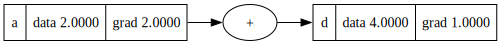

In [ ]:
#比如这个例子，d=a+a, 出现Bug, 这是因为在各个operation中没有考虑到这种情况。we need to use `+=` instead of `=` in the Value function.
a = Value(2.0, label='a')
b = Value(3.0, label='b')
d = a+a; d.label = 'd'

d.backward()
draw_dot(d)# 现在grad是2.0了, 因为前面Value的问题已经修好了

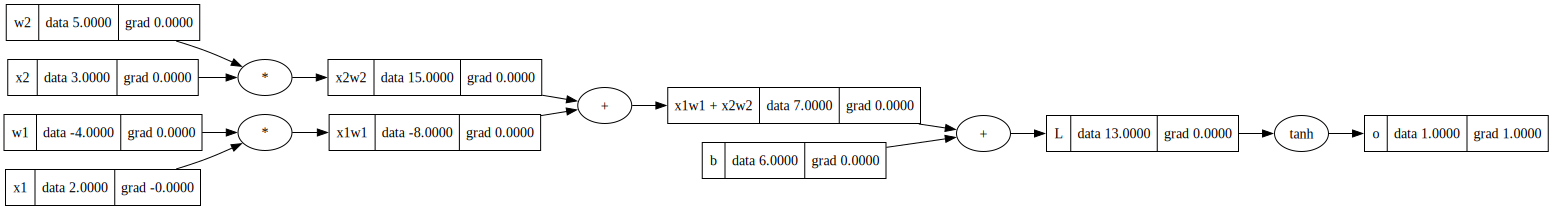

In [ ]:
o.backward()
draw_dot(o)

### <a id="s26"></a>2.6 Full Refactor — Supporting `exp`, Division & Scalar Ops

需要进一步优化+，*的过程，如multiply an int number from left side or right side:
- for left side: 加法如1+Value(1)也需要优化：
`other = other if isinstance(other, Value) else Value(other)`
代码 `isinstance(other, Value)` 的意思就是：“检查传进来的 other 到底是不是一个 Value 类的对象？

- for right side: 如Value(1)*1: 
use `__rmul__()`; When the variables at the right side can't be operated, this method will exchange the order from `self*other` to `other*self`(but remember to maintain the return self*other)

In [ ]:
from typing import Any


import math 
class Value:
    def __init__(self, data, label='', _children=(), _op=''):
        self.data=data
        self.label=label
        self._prev= set(_children)
        self._op=_op
    
    def __add__(self, other):
        other= other if isinstance(other, Value) else Value(other)
        return Value(self.data+other.data, (self, other), '+')
    
    def __radd__(self, other):
        return self+other
    
    def __mul__(self, other):
        other= other if isinstance(other, Value) else Value(other)
        return Value(self.data*other.data, (self, other), '*')
    
    def __rmul__(self, other):
        return self*other
    
a=Value(1,"a")
b=Value(2,"b")
c=b*1; c.label="c"
c.data

2

为了对Value 要素实现与tanh公式同样的计算, 我们继续定义：
- 除法:
    为了最大化复用代码，我们使用a/b=a*b**-1; 为此可以用

- exponentiation: `exp()`;
- subtraction: a-b
- negatve: 就是-1

![power-rule-formula](../Zero2Hero/img/power-rule-formula.png)

In [ ]:
def exp(self):
    x=self.data
    out= Value(math.exp(x),(self,),'exp')
    def _backward():
        self._grad += out._grad * out.data
    out._backward = _backward
    return out

def __truediv__(self, other):
    other= other if isinstance(other, Value) else Value(other)
    return Value(self.data*other.data**-1, (self, other), '/')

def __pow__(self, other):
    assert isinstance(other, (int, float)), "only support int or float" #check the type of other
    out= Value(self.data**other, (self,), f'**{other}')
    
    def _backward():
        self._grad += other * (self.data**(other-1)) * out._grad
    out._backward = _backward
    return out

def __neg__(self):
    return self*-1

def __sub__(self,other):
    return self+(-other)

接下来，将左右乘法的改进，exp加入代码：

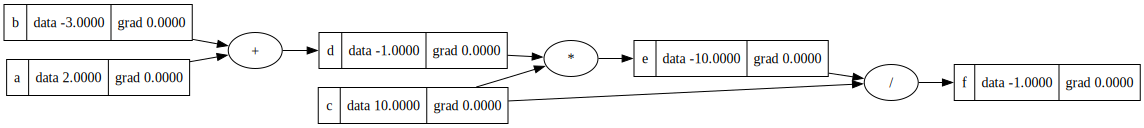

In [ ]:
## import the necessary libraries ##
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## define the Value class ##
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._grad = 0
        self.label = label
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #add the right side
        out= Value(self.data + other.data, (self, other), '+')
        def _backward():
            self._grad += 1.0 * out._grad
            other._grad += 1.0 * out._grad
        # when we call node._backward(), it will call the _backward function; for instance,h= a+b+c, when we call h._backward(), it will call the _backward function of a+b+c
        out._backward = _backward #if we add bracket here, it will call the _backward function immediately and return None; 
        #ONLY after we build the full graph, we can call the _backward function
        return out

    def __radd__(self, other): #add the left side
        return self+other #use the __add__ method
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out= Value(self.data * other.data, (self, other), '*')    
        def _backward():
            self._grad += other.data * out._grad
            other._grad += self.data * out._grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # other * self
        return self * other

    def exp(self):
        x=self.data
        out= Value(math.exp(x),(self,),'exp')
        def _backward():
            self._grad += out._grad * out.data
        out._backward = _backward
        return out

    def __truediv__(self, other):
        other= other if isinstance(other, Value) else Value(other)
        return Value(self.data*other.data**-1, (self, other), '/')

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only support int or float" #check the type of other
        out= Value(self.data**other, (self,), f'**{other}')
        
        def _backward():
            self._grad += other * (self.data**(other-1)) * out._grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self*-1

    def __sub__(self,other):
        return self+(-other)
 

    #add the tanh function
    def tanh(self):
        x=self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')
        def _backward():
            self._grad += (1-t**2) * out._grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self._grad=1.0 # 设置输出节点的梯度种子, 一定为1
        for node in reversed(topo):
            node._backward()


## define the graphviz function ##
#graphviz 
from graphviz import Digraph


# fill the nodes and edges containers
def trace(root):
    nodes, edges = set(), set()
    def build(v):#v is a node
        if v not in nodes: #nodes is a union of set
            nodes.add(v)# fill the nodes container
            # now we need to fill the edges container
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

#draw the computation flow chart
def draw_dot(root):
    #get data from the root
    #set the format of the graph,让图从左往右流向（符合直觉）
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    #get the nodes and edges
    nodes, edges = trace(root)
    for n in nodes:
        # get the unique id of the node
        uid=str(id(n))
        # set the format of the node,what to show in the node
        label = "{ %s | data %.4f | grad %.4f }" %(n.label, n.data, n._grad) #define what to show in the node
        dot.node(name=uid, label=label, shape='record')#these 3 parameters are basic
        if n._op:
            dot.node(name=uid + n._op, label = n._op)#define the operator,what to show in the operator
            dot.edge(uid + n._op, uid)#define the edge, <from the operator to the node>
    
    for n1, n2 in edges:#n1 is children, n2 is parent
        dot.edge(str(id(n1)), str(id(n2)) + n2._op) #from the children to the operator
    return dot
    
## define the expression ##
# 初始化输入变量（带标签，方便画图）
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

## operation ##
# 加法
d = a+b; d.label = 'd'
# 乘法
e = d*c; e.label = 'e'
# 除法
f = e/c; f.label = 'f'
draw_dot(f)

Now we set up an expression including the format of tanh that we want.

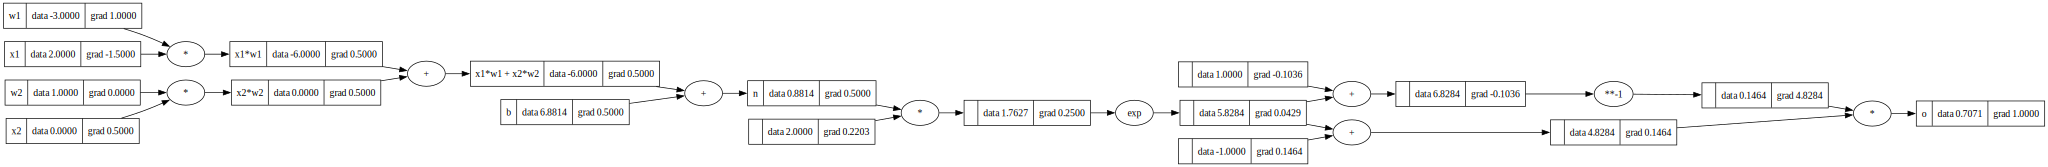

In [40]:
#graphviz 
from graphviz import Digraph
import math
import numpy as np

# fill the nodes and edges containers
def trace(root):
    nodes, edges = set(), set()
    def build(v):#v is a node
        if v not in nodes: #nodes is a union of set
            nodes.add(v)# fill the nodes container
            # now we need to fill the edges container
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

#draw the computation flow chart
def draw_dot(root):
    #get data from the root
    #set the format of the graph,让图从左往右流向（符合直觉）
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    #get the nodes and edges
    nodes, edges = trace(root)
    for n in nodes:
        # get the unique id of the node
        uid=str(id(n))
        # set the format of the node,what to show in the node
        label = "{ %s | data %.4f | grad %.4f }" %(n.label, n.data, n._grad) #define what to show in the node
        dot.node(name=uid, label=label, shape='record')#these 3 parameters are basic
        if n._op:
            dot.node(name=uid + n._op, label = n._op)#define the operator,what to show in the operator
            dot.edge(uid + n._op, uid)#define the edge, <from the operator to the node>
    
    for n1, n2 in edges:#n1 is children, n2 is parent
        dot.edge(str(id(n1)), str(id(n2)) + n2._op) #from the children to the operator
    return dot
    
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._grad = 0
        self.label = label
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other= other if isinstance(other, Value) else Value(other)
        out= Value(self.data + other.data, (self, other), '+')
        def _backward():
            self._grad += 1.0 * out._grad #use += instead of =
            other._grad += 1.0 * out._grad #use += instead of =
        # when we call node._backward(), it will call the _backward function; for instance,h= a+b+c, when we call h._backward(), it will call the _backward function of a+b+c
        out._backward = _backward #if we add bracket here, it will call the _backward function immediately and return None; 
        #ONLY after we build the full graph, we can call the _backward function
        return out

    
    def __radd__(self, other):
        return self+other
    
    def __mul__(self, other):
        other= other if isinstance(other, Value) else Value(other)
        out= Value(self.data * other.data, (self, other), '*')    
        def _backward():
            self._grad += other.data * out._grad #use += instead of =
            other._grad += self.data * out._grad #use += instead of =
        out._backward = _backward
        return out

    
    def __rmul__(self, other):
        return self*other


    def __truediv__(self, other):
        other= other if isinstance(other, Value) else Value(other)
        return self * other**-1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only support int or float" #check the type of other
        out= Value(self.data**other, (self,), f'**{other}')
        
        def _backward():
            self._grad += other * (self.data**(other-1)) * out._grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self*-1

    def __sub__(self,other):
        return self+(-other)
    
    def tanh(self):
        x=self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')
        def _backward():
            self._grad += (1-t**2) * out._grad
        out._backward = _backward
        return out

    def exp(self):
        x=self.data
        out= Value(math.exp(x),(self,),'exp')
        def _backward():
            self._grad += out._grad * out.data
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self._grad=1.0 # 设置输出节点的梯度种子, 一定为1
        for node in reversed(topo):
            node._backward()


    # inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

# -----
e = (2 * n).exp()
o = (e - 1) / (e + 1)
# -----

o.label = 'o'
o.backward()

draw_dot(o)

# 3. Use torch Tensor for backpropagation

## 3.1 了解数据类型

In [34]:
import torch

In [35]:
torch.Tensor([2.0]).double().dtype #float64
torch.Tensor([0.0]).dtype #float32
torch.Tensor([-3.0]).half().dtype #float16

torch.float16

下面是一个包含正向计算和back propagation的example

In [36]:
x1 = torch.Tensor([2.0]).double()
x2 = torch.Tensor([0.0]).double()
w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()
b = torch.Tensor([6.8813735870195432]).double()

x1.requires_grad = True #实际上我们不会对数据x1,x2进行求导，而是对权重w1,w2求导；这里只是为了和之前的代码的结果进行对比
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())

o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## 3.2 单个神经元（Neuron）
这段代码是在定义神经网络中最基础的构建块：单个神经元（Neuron）

image: ![神经网络](/Users/wangzhijie/Documents/GitHub/DeepL/resource/typical_neural_network.png)

In [ ]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] #列表推导式（List Comprehension）,输出[Value(random.uniform(-1,1)), Value(random.uniform(-1,1)), Value(random.uniform(-1,1))]
        self.b = Value(random.uniform(-1,1))#随机初始化权重和偏置

    def __call__(self, x):
        # w * x + b
        # 计算加权和
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        '''
        zip 是 Python 的一个内置函数，它的作用就像一根拉链（zipper），把两个列表对应位置的元素“咬合”在一起，打包成一个个元组（Tuple）。
        • 假设当前神经元有 3 个权重：self.w = [w1, w2, w3]  
        • 同时接收到 3 个输入信号：x = [x1, x2, x3]
        • 执行 zip(self.w, x) 后，它在底层生成的结果等价于：[(w1, x1), (w2, x2), (w3, x3)]。
        '''
        # 应用激活函数
        out=act.tanh()
        return out

## 3.3 单层（含多个Neurons)

In [ ]:
class Layer:
    def __init__(self, nin, nout): #nin, nout 是神经元输入和输出的数量
        self.neurons = [Neuron(nin) for _ in range(nout)] #列表推导式（List Comprehension）,输出[Neuron(nin), Neuron(nin), Neuron(nin)], 一层里输出nout个神经元

    def __call__(self, x):
        outs = [n(x) for n in self.neurons] #将刚才的神经元应用到输入x上，输出outs，是一个包含nout个神经元输出的列表
        return outs[0] if len(outs) == 1 else outs #如果只有一个神经元，则返回一个值，否则返回一个列表;没有数学意义，只是接口优化,减少列表访问的代码，直接输出结果


## 3.4 MLP（定义输入向量尺寸？多少输出层及每层神经元数量？）

In [ ]:

#这段 MLP 代码的作用就是将多个层顺序堆叠起来，形成一个完整的神经网络#
class MLP:
    def __init__(self, nin, nouts):
        '''
       
        eg: n = MLP(3, [4,4,1]), 	
        nin: 输入层的神经元数量,3
        nouts: 输出层的神经元数量, [4,4,1]
        输入 3 个特征:
        •	第一层 4 个神经元
        •	第二层 4 个神经元
        •	第三层 1 个神经元（可以理解为输出层）
        '''
        sz = [nin] + nouts #将两个列表进行拼接
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #这里可以生成多个Layer，将每个layer对应的nin, nouts进行传递，每个Layer包含多个Neuron

    def __call__(self, x): #__call__ 让“对象”变成“函数”, 让对象可以像函数一样被调用
        for layer in self.layers: #将每个layer应用到输入x上，输出outs，是一个包含nout个神经元输出的列表;eg Layer(3,4),Layer(4,4),Layer(4,1)
            x = layer(x) #将x作为参数传递给layer，layer返回一个包含nout个神经元输出的列表
        return x

In [ ]:
x =[2.0,3.0,-1.0]
n = MLP(3, [4,4,1]) #定义一个MLP，输入3个特征，输出1个特征，中间有2层，每层4个神经元
n(x)

Value(data=0.4747650357951468)

In [ ]:
draw_dot(n(x))

## 3.5 Dataset + Loss Function

In [45]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.4747650357951468),
 Value(data=0.7335081497386661),
 Value(data=-0.14376374753366897),
 Value(data=0.4946261779617776)]

In [ ]:
[(yout-ygt)**2 for ygt, yout in zip(ys, ypred)] #单项损失函数

[Value(data=0.2758717676232735),
 Value(data=3.0050505052103733),
 Value(data=0.7331405200375867),
 Value(data=0.25540270000152093)]

In [48]:
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) #损失函数
loss

Value(data=4.2694654928727545)

In [50]:
loss.backward()

In [51]:
n.layers[0].neurons[0].w[0]._grad

-1.0875581385447688

In [ ]:
draw_dot(loss)

进一步修改class Neuron, class Layer and class MLP to print the parameters:
- because训练流程是：
1. forward 计算预测值
2. 计算 loss
3. backward 计算梯度
4. 更新所有权重
第 4 步非常重要：

你必须知道“有哪些参数要更新”

这就是 parameters() 存在的原因。
- 为什么设计成一层层收集？
因为这是“组合模式”设计：
MLP
  └── Layer
        └── Neuron
              └── w, b
每一层只负责：

👉 收集自己的参数
👉 交给上一层

非常干净的设计。

In [134]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] #列表推导式（List Comprehension）,输出[Value(random.uniform(-1,1)), Value(random.uniform(-1,1)), Value(random.uniform(-1,1))]
        self.b = Value(random.uniform(-1,1))#随机初始化权重和偏置

    def __call__(self, x):
        # w * x + b
        # 计算加权和
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        '''
        zip 是 Python 的一个内置函数，它的作用就像一根拉链（zipper），把两个列表对应位置的元素“咬合”在一起，打包成一个个元组（Tuple）。
        • 假设当前神经元有 3 个权重：self.w = [w1, w2, w3]  
        • 同时接收到 3 个输入信号：x = [x1, x2, x3]
        • 执行 zip(self.w, x) 后，它在底层生成的结果等价于：[(w1, x1), (w2, x2), (w3, x3)]。
        '''
        # 应用激活函数
        out=act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b] # 返回所有参数

class Layer:
    def __init__(self, nin, nout): #nin, nout 是神经元输入和输出的数量
        self.neurons = [Neuron(nin) for _ in range(nout)] #列表推导式（List Comprehension）,输出[Neuron(nin), Neuron(nin), Neuron(nin)], 一层里输出nout个神经元

    def __call__(self, x):
        outs = [n(x) for n in self.neurons] #将刚才的神经元应用到输入x上，输出outs，是一个包含nout个神经元输出的列表
        return outs[0] if len(outs) == 1 else outs #如果只有一个神经元，则返回一个值，否则返回一个列表;没有数学意义，只是接口优化,减少列表访问的代码，直接输出结果

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()] #返回所有神经元的参数
        ''' params = []
            for neuron in self.neurons: #外层循环 → 遍历每个神经元
                for p in neuron.parameters(): #内层循环 → 遍历该神经元的每个参数，如[w21, w22, b2]
                    params.append(p) #append → 收集起来，如params = [w11, w12, b1, w21, w22, b2]
            return params
        '''

class MLP:
    def __init__(self, nin, nouts):
        '''
       
        eg: n = MLP(3, [4,4,1]), 	
        nin: 输入层的神经元数量,3
        nouts: 输出层的神经元数量, [4,4,1]
        输入 3 个特征:
        •	第一层 4 个神经元
        •	第二层 4 个神经元
        •	第三层 1 个神经元（可以理解为输出层）
        '''
        sz = [nin] + nouts #将两个列表进行拼接
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #这里可以生成多个Layer，将每个layer对应的nin, nouts进行传递，每个Layer包含多个Neuron

    def __call__(self, x): #__call__ 让“对象”变成“函数”, 让对象可以像函数一样被调用
        for layer in self.layers: #将每个layer应用到输入x上，输出outs，是一个包含nout个神经元输出的列表;eg Layer(3,4),Layer(4,4),Layer(4,1)
            x = layer(x) #将x作为参数传递给layer，layer返回一个包含nout个神经元输出的列表
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()] #返回所有层的参数

In [135]:
n = MLP(3, [4,4,1]) #定义一个MLP，输入3个特征，输出1个特征，中间有2层，每层4个神经元
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets


In [124]:
ypred = [n(x) for x in xs]
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) #损失函数
loss

Value(data=0.0005749428239128588)

In [125]:
loss.backward()

In [ ]:
for p in n.parameters():
    p.data += -0.01 * p._grad #-0.01 是学习率,converge faster if set to 0.1
ypred

[Value(data=0.9950215153976507),
 Value(data=-0.9921551775229512),
 Value(data=-0.9786237600773152),
 Value(data=0.9943721547597293)]

In [ ]:
for k in range(100):
    #forward pass   
    ypred = [n(x) for x in xs]
    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) #损失函数
    #backward pass
    for p in n.parameters():
        p._grad = 0 #reset gradient
    loss.backward()
    #update parameters
    for p in n.parameters():
        p.data += -0.1 * p._grad #-0.01 是学习率,converge faster if set to 0.1
    #print loss
    print(k, loss.data)
    

0 0.08012923042864695
1 0.06976819149505983
2 0.06180622462404349
3 0.05541235391199364
4 0.05014549570531436
5 0.04572973237149209
6 0.041976385206279596
7 0.038749688686248
8 0.03594870467158584
9 0.03349660055631874
10 0.03133380147709465
11 0.02941339906062321
12 0.02769796679013036
13 0.0261572938453346
14 0.02476673914598
15 0.023506015134859615
16 0.02235827561785177
17 0.02130942256600907
18 0.020347573038158366
19 0.019462644801237987
20 0.018646031028587987
21 0.01789034259943314
22 0.01718920223014338
23 0.016537078724852064
24 0.015929152553921997
25 0.01536120609641584
26 0.014829533449350164
27 0.014330865871611156
28 0.013862309804996309
29 0.013421295077097752
30 0.013005531396327614
31 0.012612971638341387
32 0.012241780724527663
33 0.011890309128407443
34 0.011557070230479211
35 0.011240720887984433
36 0.010940044702063268
37 0.010653937557478763
38 0.010381395084578192
39 0.010121501753316685
40 0.009873421357980671
41 0.009636388691046126
42 0.00940970223718748
43 0

总结神经网络中最常见的一些错误。他列举了几个新手（甚至有经验的人）经常犯的问题：

主要包括：

	1.	没有先尝试让模型对一个 batch 过拟合（overfit）
👉 训练前应该先看看模型能否在一个小批次数据上完全拟合，这是最基本的 sanity check。

	2.	忘记在训练和测试时切换 train / eval 模式
👉 在 PyTorch 里需要用 model.train() 和 model.eval()。
特别是 BatchNorm 和 Dropout 层在两种模式下行为不同。

	3.	在 PyTorch 中忘记在 backward() 前调用 .zero_grad()
👉 不清零梯度会导致梯度累积，从而训练异常。

	4.	把 softmax 之后的输出传给一个期望 raw logits 的 loss
👉 例如 CrossEntropyLoss 本身内部就包含了 softmax，
如果你提前做 softmax，会导致训练不正常。

然后他在回复中补充了第 5 点：

	5.	在使用 BatchNorm 时忘记把 Linear/Conv 层的 bias 设为 False
或者相反，在输出层忘记加 bias。

整体来说，这条推文是在提醒大家：
很多神经网络训练问题其实不是模型结构的问题，而是这些基础细节没处理好。

Links:

- micrograd on github: https://github.com/karpathy/micrograd

- jupyter notebooks I built in this video: https://github.com/karpathy/nn-zero-t...

- my website: https://karpathy.ai

- my twitter:   / karpathy  

- "discussion forum": nvm, use youtube comments below for now :)
(new) Neural Networks: Zero to Hero series Discord channel:   / discord   , for people who'd like to chat more and go beyond youtube comments

- Exercises:

you should now be able to complete the following google collab, good luck!:
https://colab.research.google.com/dri...
